# LeetCode #121: Best Time to Buy and Sell Stock

https://leetcode.com/problems/best-time-to-buy-and-sell-stock/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^2)$ | $O(1)$ |
| **Greedy (One Pass)** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Try every pair (i, j) where i < j and compute prices[j] − prices[i], keeping the maximum. Each of the $O(n^2)$ pairs is checked independently with no reuse of prior comparisons.

### Optimal: Greedy (One Pass) ★
Scan left to right, maintaining the lowest price seen so far. At each day, the best possible profit if selling today is price − minPrice. Track the running maximum of those profits. One pass, two variables.

**Why this is better than Brute Force:** Fixing a sell day j no longer requires re-scanning all prior buy days — the running minimum already encodes the cheapest valid buy. This drops the inner loop entirely: $O(n^2)$ → $O(n)$.

**Constraints:**
* 1 ≤ prices.length ≤ 10⁵
* 0 ≤ prices[i] ≤ 10⁴

## Solutions

### C#

In [ ]:
public class Solution {
    public int MaxProfit(int[] prices) {
        int minPrice = int.MaxValue, maxProfit = 0;
        foreach (int price in prices) {
            // Cheapest buy day seen so far
            if (price < minPrice) minPrice = price;
            // Best profit if selling today
            else if (price - minPrice > maxProfit) maxProfit = price - minPrice;
        }
        return maxProfit;
    }
}

### Python

In [ ]:
class Solution:
    def maxProfit(self, prices: List[int]) -> int:
        min_price, max_profit = float('inf'), 0
        for price in prices:
            # Cheapest buy day seen so far
            if price < min_price:
                min_price = price
            # Best profit if selling today
            elif price - min_price > max_profit:
                max_profit = price - min_price
        return max_profit

### Go

In [ ]:
import "math"

func maxProfit(prices []int) int {
    minPrice, maxProfit := math.MaxInt32, 0
    for _, price := range prices {
        // Cheapest buy day seen so far
        if price < minPrice {
            minPrice = price
        // Best profit if selling today
        } else if price-minPrice > maxProfit {
            maxProfit = price - minPrice
        }
    }
    return maxProfit
}

### Rust

In [ ]:
pub fn max_profit(prices: Vec<i32>) -> i32 {
    let mut min_price = i32::MAX;
    let mut max_profit = 0;
    for price in prices {
        // Cheapest buy day seen so far
        if price < min_price {
            min_price = price;
        // Best profit if selling today
        } else if price - min_price > max_profit {
            max_profit = price - min_price;
        }
    }
    max_profit
}

## Example Scenarios

**1. Common Case**
**Input:** prices = [7, 1, 5, 3, 6, 4]
minPrice hits 1 at day 1; selling at 5 gives profit 4; selling at 6 gives profit 5. Final **maxProfit = 5** (buy day 1, sell day 4).

**2. Slightly Complex — min resets mid-array**
**Input:** prices = [7, 2, 4, 1, 6]
Day 1: minPrice=2. Day 2: profit=4−2=2. Day 3: minPrice resets to 1 (lower than 2). Day 4: profit=6−1=5 > 2 → maxProfit=5. The running minimum correctly abandons the earlier buy opportunity at 2 once a cheaper price appears. Final **maxProfit = 5**.

**3. Edge Case: Time Factor — monotonically decreasing prices**
**Input:** prices = [9, 7, 4, 2, 1]
Every day sets a new minPrice; the `else if` branch (profit update) never executes because `price < minPrice` is always true. All $n$ iterations update minPrice only — zero profit computations wasted. Brute Force still evaluates all $O(n^2) = 10$ pairs. Returns **0** (no profitable trade possible).

**4. Edge Case: Space Factor — always O(1)**
**Input:** prices = [1, 2, 3, 4, 5] (monotonically increasing, $n = 10^5$)
Only two integers are ever held: minPrice and maxProfit. Regardless of input size, no array, stack, or map is created. minPrice stays at 1; each subsequent day updates maxProfit to 1, 2, 3, 4. Final **maxProfit = 4**. Brute Force needs no extra space either — the O(1) claim is equal. What differs is that Brute Force's time grows to $O(n^2) \approx 10^{10}$ while Greedy stays $O(n)$.

**5. Almost-Impossible but Plausible — single element**
**Input:** prices = [42]  \|  length = 1
The loop runs once: price=42 < int.MaxValue → minPrice=42. The `else if` branch is skipped. Loop exits. maxProfit = **0** — correct, since you must buy before you sell and there is no day after day 0.

## Infographic

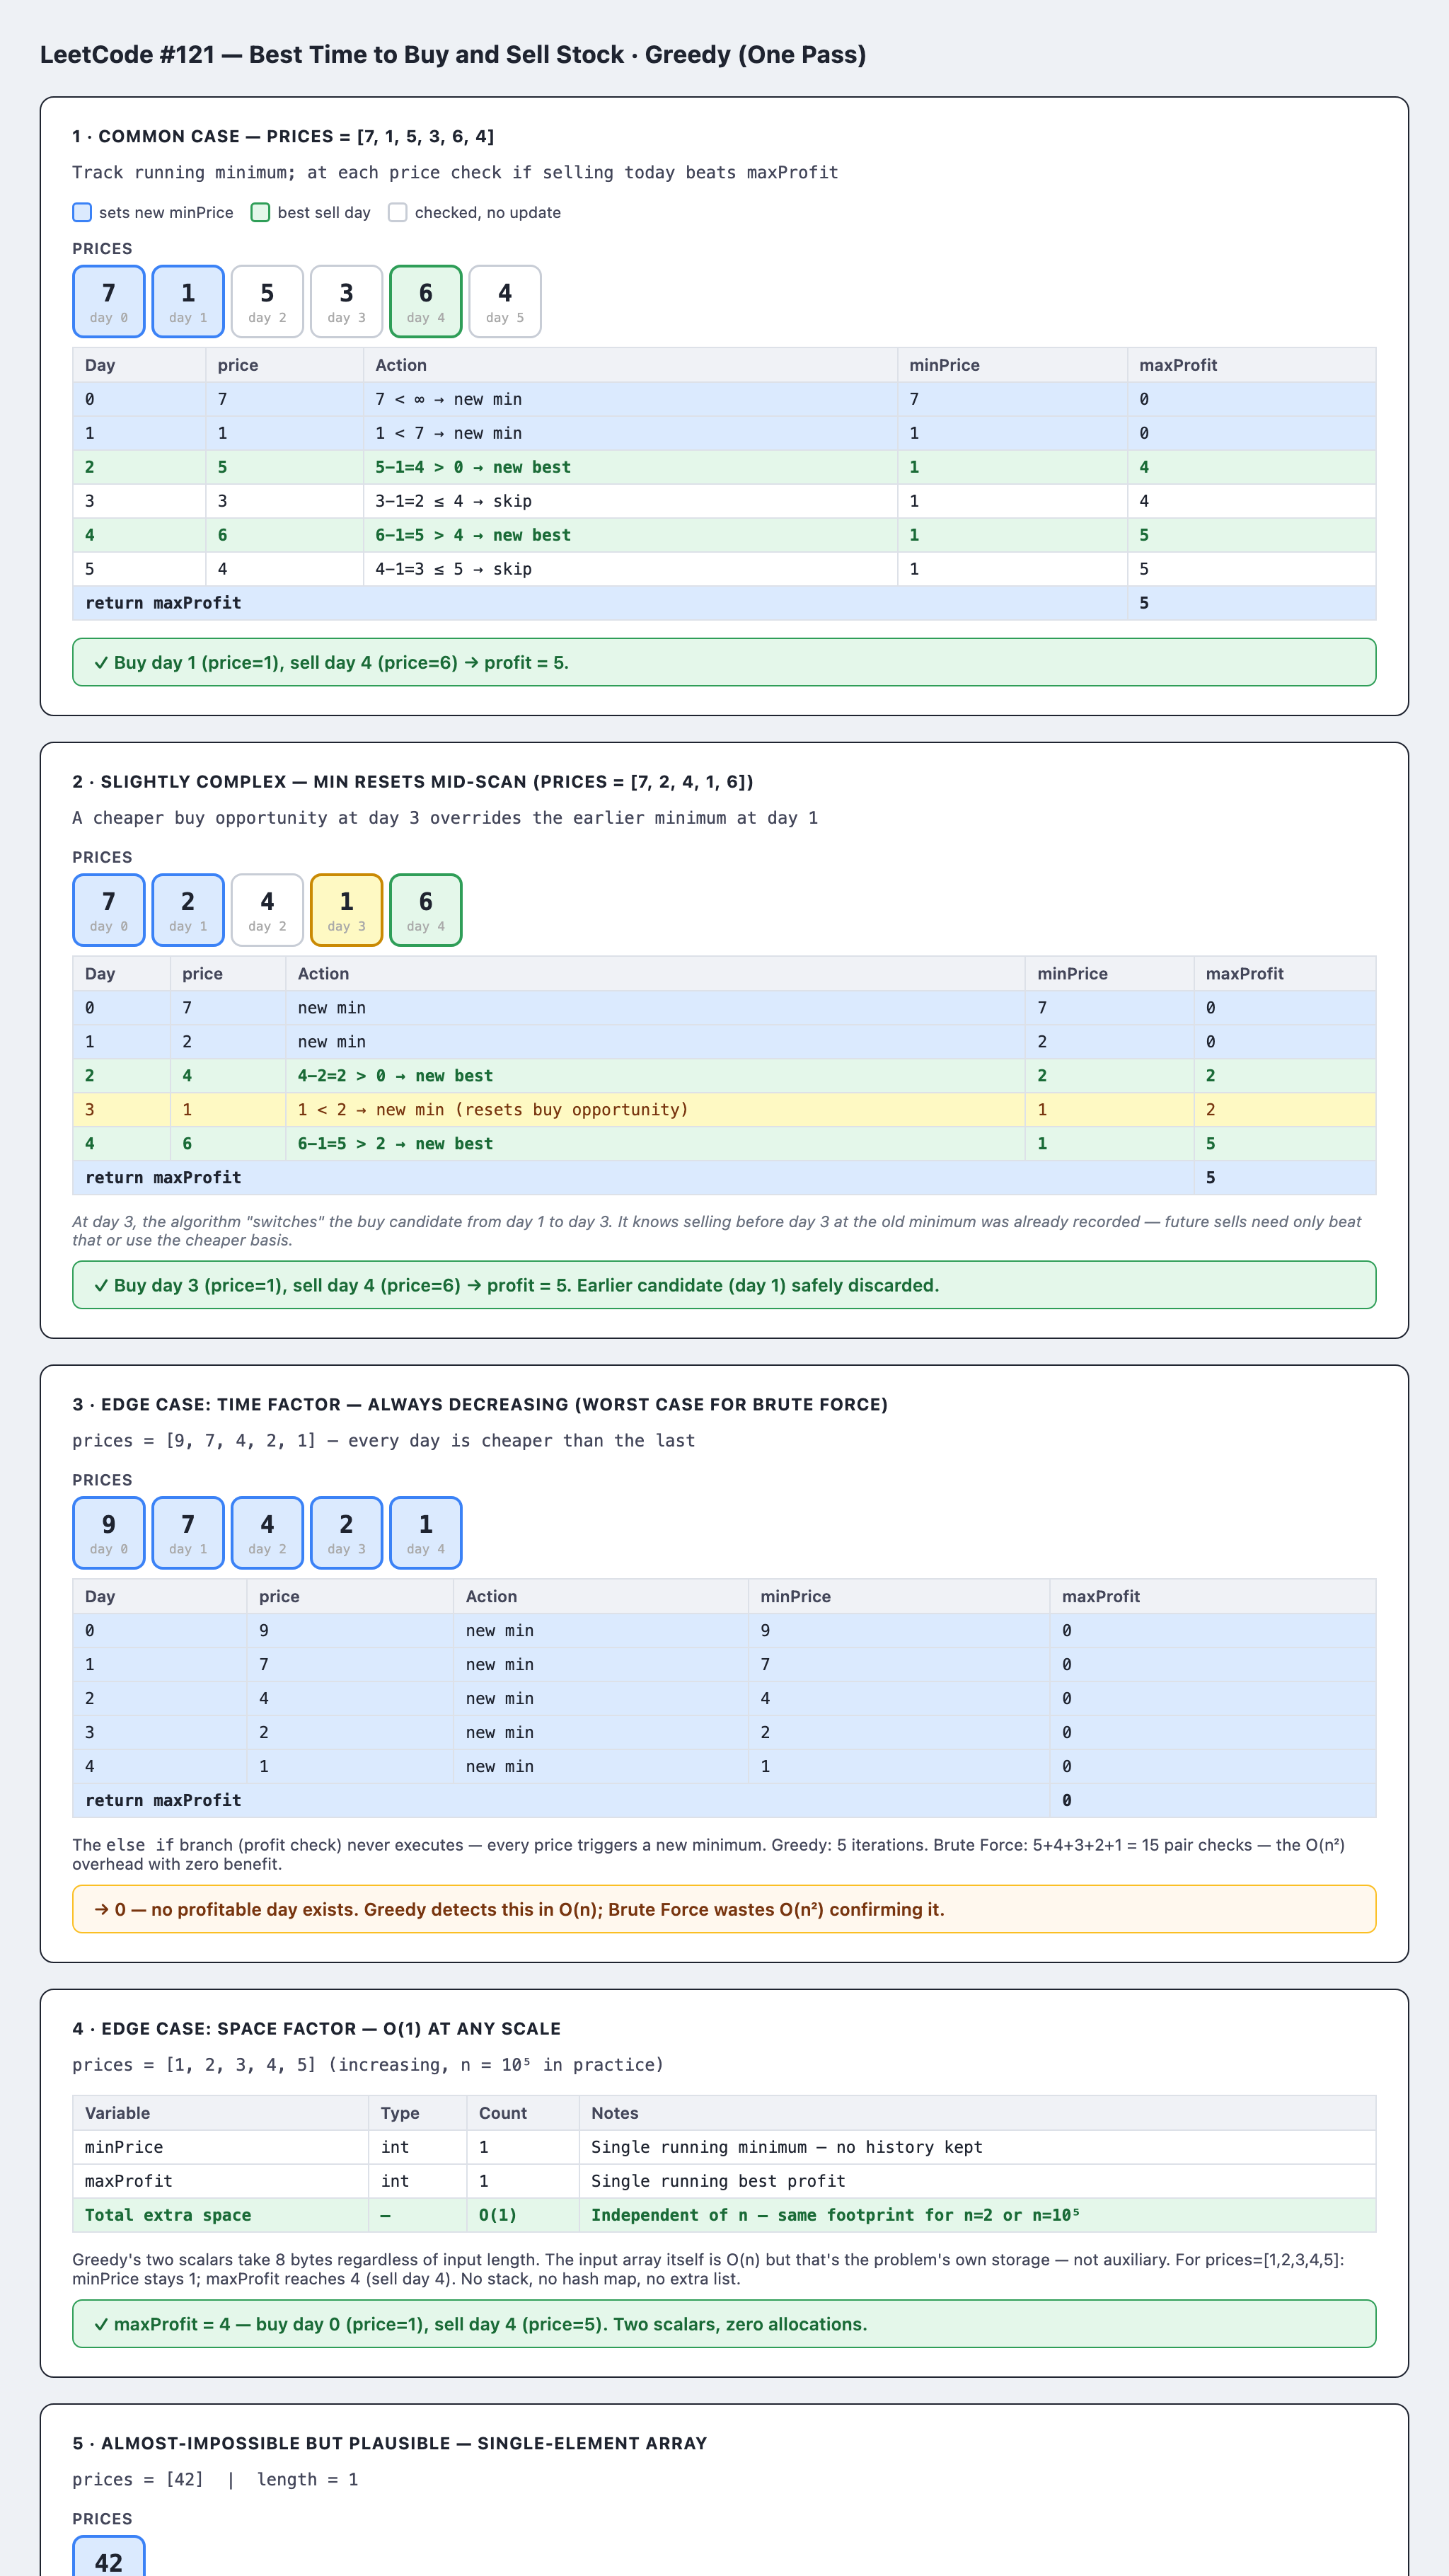